In [1]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import jax
import jax.numpy as jnp
from waymax import config, dataloader, dynamics, env, datatypes, visualization
import matplotlib.pyplot as plt

print(jax.devices())

I0000 00:00:1774465166.962699   58923 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[CudaDevice(id=0)]


In [2]:
data_config = config.DatasetConfig(
    path='gs://waymo_open_dataset_motion_v_1_2_0/uncompressed/tf_example/training/training_tfexample.tfrecord-00000-of-01000',
    max_num_objects=16,
)

scenarios = dataloader.simulator_state_generator(data_config)
scenario = next(scenarios)

print(type(scenario))
print(scenario.shape)
print(f"Num objects: {scenario.num_objects}")
print(f"Num timesteps: {scenario.sim_trajectory.num_timesteps}")

I0000 00:00:1774465201.740654   59317 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


<class 'waymax.datatypes.simulator_state.SimulatorState'>
()
Num objects: 16
Num timesteps: 91


In [ ]:
# Cell: what is the SDC? -- self-driving car --> our agent
print(scenario.object_metadata.is_sdc)
print(scenario.object_metadata.is_sdc.shape)

[False  True False False False False False False False False False False
 False False False False]
(16,)


## Object types come from ObjectTypeIds:

* 0 = Unset
* 1 = Vehicle
* 2 = Pedestrian
* 3 = Cyclist
* 4 = Other

In [4]:
# Cell: what types of objects are there?
print(scenario.object_metadata.object_types)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [5]:
# Cell: which objects are valid?
print(scenario.object_metadata.is_valid)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]


In [6]:
# Cell: look at the SDC's current position
traj = scenario.sim_trajectory
print(f"x shape: {traj.x.shape}")
print(f"SDC x over time: {traj.x[1]}")  # index 1 is the SDC
print(f"SDC y over time: {traj.y[1]}")

x shape: (16, 91)
SDC x over time: [350.06186   0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.        0.        0.        0.        0.        0.     ]
SDC y over time: [150.71342   0.        0.        0.        0.        0.        0.
   0.        0.   

### Trajectories
* log_trajectory = the full recorded ground truth for all 91 timesteps — where the human driver actually went
* sim_trajectory = what the agent has done so far in the simulation 
    * starts with only timestep 0 filled in, gets populated as you call step()

In [7]:
# Cell: compare sim_trajectory vs log_trajectory
print("sim x:", scenario.sim_trajectory.x[1, :5])   # first 5 timesteps
print("log x:", scenario.log_trajectory.x[1, :5])   # first 5 timesteps

sim x: [350.06186   0.        0.        0.        0.     ]
log x: [350.06186 350.72552 351.38367 352.04102 352.69696]


In [9]:
# Cell: set up the environment
dynamics_model = dynamics.InvertibleBicycleModel()
env_config = config.EnvironmentConfig(max_num_objects=16) # By defaults, max_num_objects=128
waymax_env = env.PlanningAgentEnvironment(dynamics_model, env_config)

# Reset to get initial state
state = waymax_env.reset(scenario)
print(f"timestep: {state.timestep}")
print(f"is_done: {state.is_done}")

timestep: 10
is_done: False


#####  DatasetConfig and EnvironmentConfig must always have matching max_num_objects

## Expert action

In [13]:
from waymax import agents

expert_actor = agents.create_expert_actor(dynamics_model)
actor_state = expert_actor.init(jax.random.PRNGKey(0), state)
action = expert_actor.select_action(params=None, state=state, actor_state=None, rng=None)

print(f"action data shape: {action.action.data.shape}")
print(f"action valid shape: {action.action.valid.shape}")
print(f"SDC action: {action.action.data[1]}")
print(f"SDC valid: {action.action.valid[1]}")

action data shape: (16, 2)
action valid shape: (16, 1)
SDC action: [-4.0557861e-01 -1.9343873e-04]
SDC valid: [ True]


In [19]:
action.action.data.shape

(16, 2)

## Actions
* data[0] = acceleration (m/s²) — negative here means the SDC is decelerating
* data[1] = steering angle (radians) — nearly zero here means going roughly straight

In [15]:
print(f"action.action.data.shape: {action.action.data.shape}")
print(f"action.action.valid.shape: {action.action.valid.shape}")
print(f"action.action.shape: {action.action.shape}")

action.action.data.shape: (16, 2)
action.action.valid.shape: (16, 1)
action.action.shape: (16,)


In [16]:
# # Step the environment with the expert action
# next_state = waymax_env.step(state, action.action)

# print(f"timestep before: {state.timestep}")
# print(f"timestep after: {next_state.timestep}")
# print(f"SDC x before: {state.current_sim_trajectory.x[1]}")
# print(f"SDC x after: {next_state.current_sim_trajectory.x[1]}")

In [ ]:
env_config = config.EnvironmentConfig(max_num_objects=16)
waymax_env_base = env.BaseEnvironment(dynamics_model, env_config)
state_base = waymax_env_base.reset(scenario)

print(f"timestep: {state.timestep}")
print(f"is_done: {state.is_done}")

timestep: 10
is_done: False


## Full episode loop

In [41]:
dynamics_model = dynamics.InvertibleBicycleModel()
env_config = config.EnvironmentConfig(max_num_objects=16)
waymax_env = env.BaseEnvironment(dynamics_model, env_config)
expert_actor = agents.create_expert_actor(dynamics_model)

state = waymax_env.reset(scenario)

sdc_x = []
sdc_y = []

while not state.is_done:
    action = expert_actor.select_action(params=None, state=state, actor_state=None, rng=None)
    state = waymax_env.step(state, action.action)
    
    # collect SDC position — you fill this part in
    # hint: state.current_sim_trajectory.x[?]
    sdc_x.append(state.current_sim_trajectory.x[1])  # index 1 is the SDC
    sdc_y.append(state.current_sim_trajectory.y[1])  # index 1 is the SDC

print(f"Collected {len(sdc_x)} timesteps")

Collected 80 timesteps


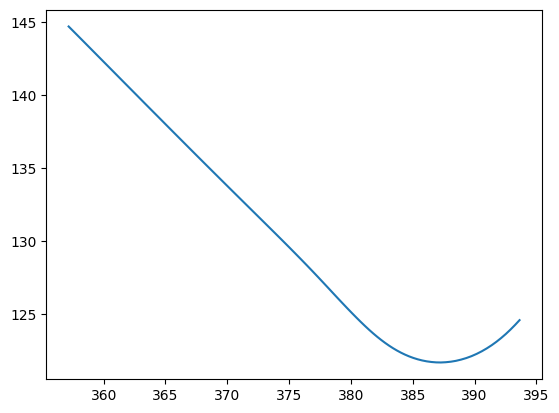

In [42]:
plt.plot(sdc_x, sdc_y)

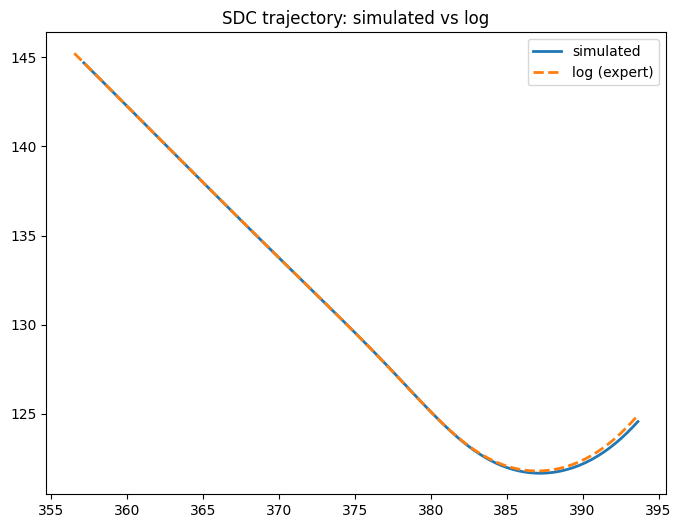

In [43]:
log_x = scenario.log_trajectory.x[1, 10:]  # skip warmup
log_y = scenario.log_trajectory.y[1, 10:]

plt.figure(figsize=(8, 6))
plt.plot(sdc_x, sdc_y, label='simulated', linewidth=2)
plt.plot(log_x, log_y, label='log (expert)', linewidth=2, linestyle='--')
plt.legend()
plt.title('SDC trajectory: simulated vs log')
plt.show()

## Visualize the full scene

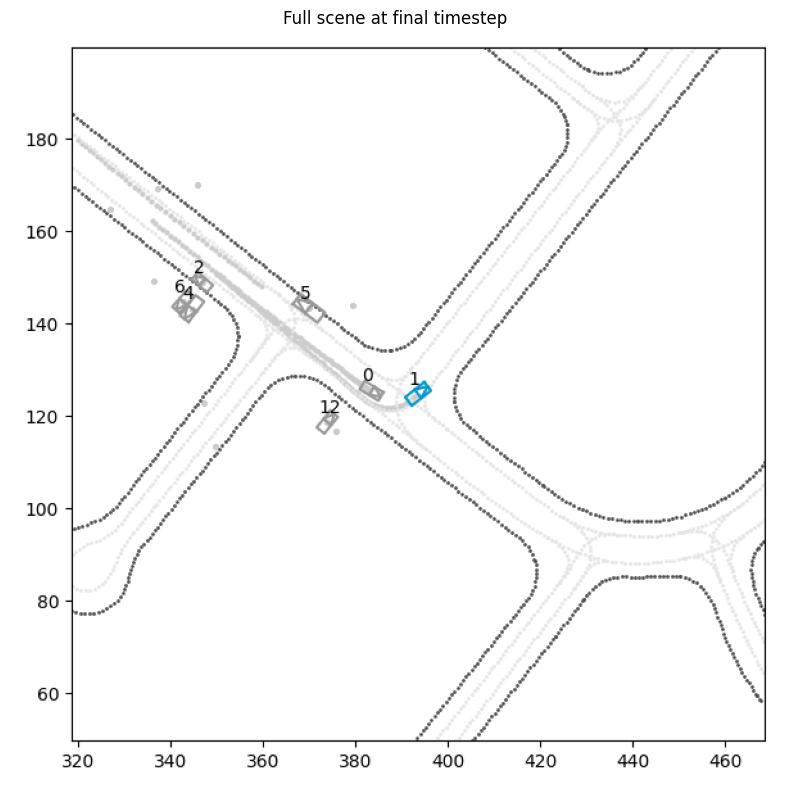

In [44]:
img = visualization.plot_simulator_state(state, use_log_traj=True)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.title('Full scene at final timestep')
plt.show()

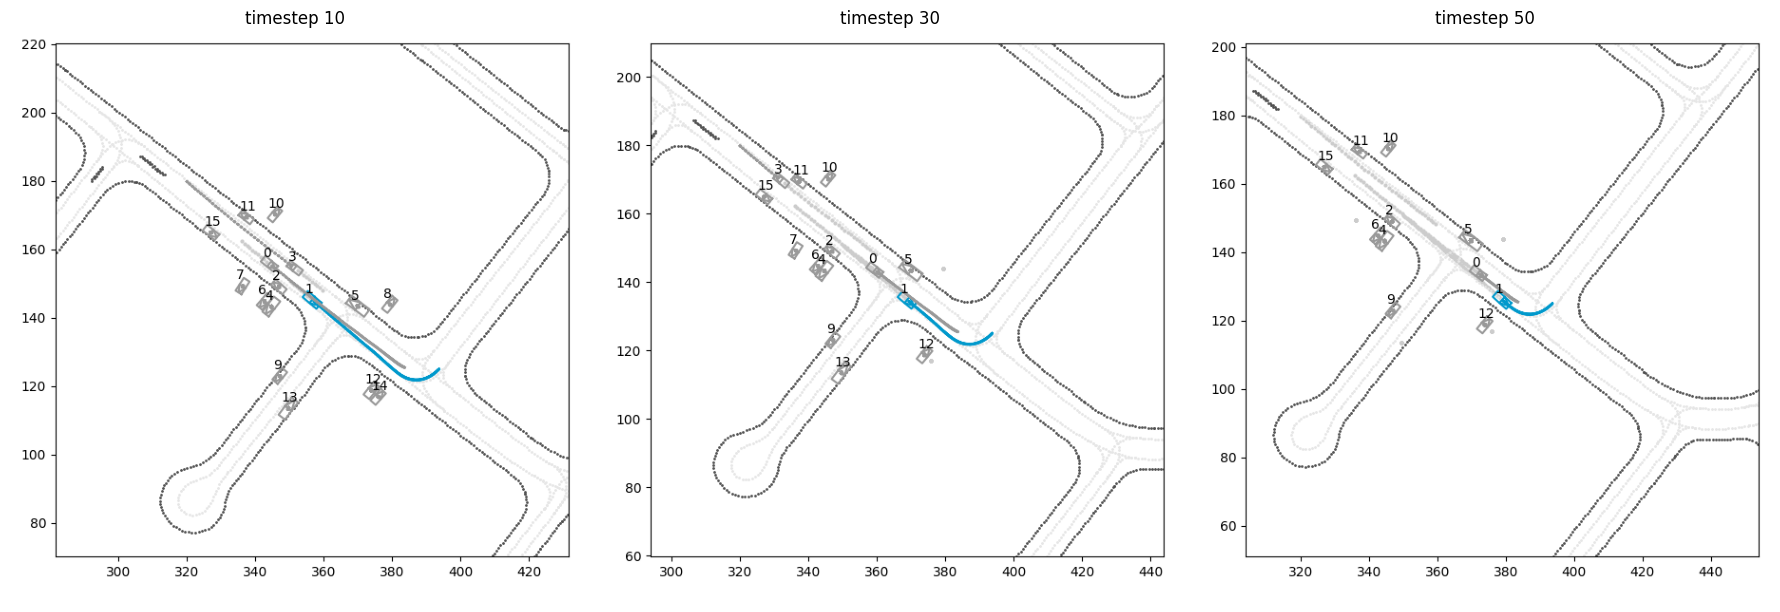

In [45]:
state = waymax_env.reset(scenario)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
timesteps_to_render = [0, 20, 40]

for i, target_t in enumerate(timesteps_to_render):
    s = state
    for _ in range(target_t):
        action = expert_actor.select_action(params=None, state=s, actor_state=None, rng=None)
        s = waymax_env.step(s, action.action)
    
    img = visualization.plot_simulator_state(s, use_log_traj=True)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'timestep {s.timestep}')

plt.tight_layout()
plt.show()

In [48]:
rg = state.roadgraph_points
print(f"roadgraph_points shape: {rg.xyz.shape}")
print(f"roadgraph types: {jnp.unique(rg.types)}")
print(f"roadgraph valid: {rg.valid.sum()} valid points out of {rg.valid.shape}")

roadgraph_points shape: (30000, 3)
roadgraph types: [-1  2  9 11 12 15 16 20]
roadgraph valid: 8639 valid points out of (30000,)


In [54]:
sdc_x = state.current_sim_trajectory.x[1, 0]
sdc_y = state.current_sim_trajectory.y[1, 0]

rg_x = state.roadgraph_points.xyz[:, 0]
rg_y = state.roadgraph_points.xyz[:, 1]

distances = jnp.sqrt((rg_x - sdc_x)**2 + (rg_y - sdc_y)**2)

print(f"SDC position: ({sdc_x:.1f}, {sdc_y:.1f})")
print(f"Closest roadgraph point distance: {distances.min():.1f}m")
print(f"Furthest roadgraph point distance: {distances.max():.1f}m")
print(f"Points within 50m: {(distances < 50).sum()}")
print(f"Points within 20m: {(distances < 20).sum()}")

SDC position: (356.5, 145.2)
Closest roadgraph point distance: 1.3m
Furthest roadgraph point distance: 386.3m
Points within 50m: 1203
Points within 20m: 365


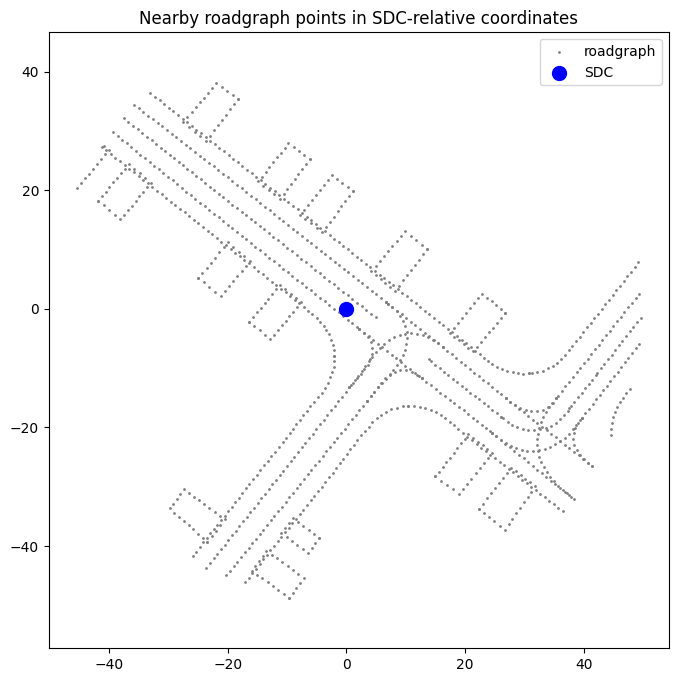

In [55]:
# Get valid points within 50m
valid_mask = state.roadgraph_points.valid & (distances < 50)

nearby_x = rg_x[valid_mask] - sdc_x  # relative to SDC
nearby_y = rg_y[valid_mask] - sdc_y

plt.figure(figsize=(8, 8))
plt.scatter(nearby_x, nearby_y, s=1, c='gray', label='roadgraph')
plt.scatter(0, 0, s=100, c='blue', label='SDC')
plt.legend()
plt.title('Nearby roadgraph points in SDC-relative coordinates')
plt.axis('equal')
plt.show()

### STATE -- What are the choice of states for our self-driving agents?

In [78]:
state.keys()

dict_keys(['sim_trajectory', 'log_trajectory', 'log_traffic_light', 'object_metadata', 'timestep', 'sdc_paths', 'roadgraph_points'])

In [71]:
state.sim_trajectory.shape

(16, 91)

* So here, we have a total of *16* entities' trajectories in *91* steps (including 10 warm up steps)

In [69]:
state.sim_trajectory.xyz[0, :5]  # first 5 timesteps of the first object (non-SDC)

Array([[ 335.9037  ,  162.36154 , -106.40682 ],
       [ 336.71204 ,  161.69809 , -106.41013 ],
       [ 337.51434 ,  161.04576 , -106.412   ],
       [ 338.3167  ,  160.40118 , -106.42465 ],
       [ 339.12952 ,  159.74545 , -106.433395]], dtype=float32)

In [70]:
state.sim_trajectory.xyz[1, :5]  # first 5 timesteps of the first object (non-SDC)

Array([[ 350.06186 ,  150.71342 , -106.063   ],
       [ 350.72552 ,  150.15756 , -106.06163 ],
       [ 351.38367 ,  149.60275 , -106.06001 ],
       [ 352.04102 ,  149.04706 , -106.061386],
       [ 352.69696 ,  148.49483 , -106.06475 ]], dtype=float32)

* Collision checking within Waymax?

In [81]:
from waymax import metrics

print(dir(metrics))

['AbstractMetric', 'LogDivergenceMetric', 'MetricResult', 'OffRouteMetric', 'OffroadMetric', 'OverlapMetric', 'ProgressionMetric', 'WrongWayMetric', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'abstract_metric', 'comfort', 'get_metric_names', 'imitation', 'metric_factory', 'overlap', 'register_metric', 'roadgraph', 'route', 'run_metrics']


In [82]:
overlap_metric = metrics.OverlapMetric()
result = overlap_metric.compute(state)
print(f"overlap values: {result.value}")
print(f"overlap valid: {result.valid}")

overlap values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
overlap valid: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]


 All zeros means no overlaps/collisions at the initial timestep — all 16 objects are valid and none are intersecting each other. Makes sense since it's the start of the scenario.

* The output tells you:
    * value — per-object collision indicator, 1.0 = colliding, 0.0 = clear
    * valid — whether the metric is meaningful for that object

In [83]:
state = waymax_env.reset(scenario)
overlap_metric = metrics.OverlapMetric()

any_collision = False
while not state.is_done:
    action = expert_actor.select_action(params=None, state=state, actor_state=None, rng=None)
    state = waymax_env.step(state, action.action)
    result = overlap_metric.compute(state)
    if result.value.max() > 0:
        any_collision = True
        print(f"Collision at timestep {state.timestep}: {result.value}")

if not any_collision:
    print("No collisions in expert episode")

No collisions in expert episode


## Action

In [84]:
# dynamics_model = dynamics.InvertibleBicycleModel()
# env_config = config.EnvironmentConfig(max_num_objects=16)
# waymax_env = env.BaseEnvironment(dynamics_model, env_config)
# expert_actor = agents.create_expert_actor(dynamics_model)

state = waymax_env.reset(scenario)

sdc_x = []
sdc_y = []

actions = []

while not state.is_done:
    action = expert_actor.select_action(params=None, state=state, actor_state=None, rng=None)
    state = waymax_env.step(state, action.action)
    actions.append(action)
    # collect SDC position — you fill this part in
    # hint: state.current_sim_trajectory.x[?]
    sdc_x.append(state.current_sim_trajectory.x[1])  # index 1 is the SDC
    sdc_y.append(state.current_sim_trajectory.y[1])  # index 1 is the SDC

print(f"Collected {len(sdc_x)} timesteps")

Collected 80 timesteps


In [87]:
import numpy as np

actions = np.array([a.action.data for a in actions])  # shape (timesteps, num_objects, action_dim)
print(f"Actions shape: {actions.shape}")
print(f"SDC actions over time: {actions[:, 1]}")  # index

Actions shape: (80, 16, 2)
SDC actions over time: [[-4.05578613e-01 -1.93438726e-04]
 [-5.07144928e-01 -9.22857260e-04]
 [-5.91144562e-01 -2.37919227e-03]
 [-3.26242447e-01 -1.30407381e-04]
 [-1.68275833e-01  1.46692514e-03]
 [-2.84461975e-01 -1.65433821e-03]
 [-2.97164917e-01 -8.81727843e-04]
 [-1.32541656e-01  3.14871501e-03]
 [-1.49059296e-02 -8.71787837e-04]
 [ 1.72896385e-01 -2.40808516e-03]
 [-2.17628479e-02  3.97605170e-03]
 [-6.87503815e-02  8.23537994e-04]
 [ 2.85978317e-01 -2.66952533e-03]
 [ 3.57341766e-01  2.53413408e-03]
 [ 2.18944550e-01  1.85352610e-03]
 [ 1.90639496e-02 -7.60775874e-04]
 [-3.09934616e-01  1.17437262e-03]
 [-6.86154366e-01  2.51485640e-03]
 [-6.53905869e-01  1.36119989e-03]
 [-5.75704575e-01  1.41739473e-03]
 [-6.46409988e-01  8.18604531e-05]
 [-7.94162750e-01  9.17112920e-04]
 [-9.81230736e-01  2.33048992e-03]
 [-1.05286121e+00  2.23553106e-05]
 [-1.05296612e+00 -2.68534262e-04]
 [-1.06321335e+00  7.58881913e-04]
 [-1.19074821e+00 -1.71404984e-03]
 [-1.

The two numbers in action.data[1] for **InvertibleBicycleModel** are:

* data[0] = acceleration in m/s²
    * positive = speeding up
    * negative = braking
    * zero = constant speed


* data[1] = steering angle in radians
    * positive = turning left
    * negative = turning right
    * zero = straight